In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/berlin_airbnb_cleaned.csv", encoding='utf-8')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  4999 non-null   int64  
 1   Review ID              4942 non-null   float64
 2   review_date            4942 non-null   str    
 3   Reviewer ID            4942 non-null   float64
 4   Reviewer Name          4942 non-null   str    
 5   Comments               4939 non-null   str    
 6   Listing ID             4999 non-null   int64  
 7   Listing URL            4999 non-null   str    
 8   Listing Name           4997 non-null   str    
 9   Host ID                4999 non-null   int64  
 10  Host URL               4999 non-null   str    
 11  Host Name              4998 non-null   str    
 12  Host Since             4998 non-null   str    
 13  Host Response Time     4366 non-null   str    
 14  Host Response Rate     4366 non-null   str    
 15  Is Superhost   

In [6]:
# 1. Overall Descriptive Statistics for the entire dataset
overall_stats = df['Price'].agg(['mean', 'median', 'std', 'count']).to_frame().T
overall_stats.columns = ['Mean_Mittelwert', 'Median_Zentralwert', 'Standard_Dev_Price', 'Total_Listings']

print("--- OVERALL BERLIN AIRBNB STATS ---")
print(overall_stats.round(2))

--- OVERALL BERLIN AIRBNB STATS ---
       Mean_Mittelwert  Median_Zentralwert  Standard_Dev_Price  Total_Listings
Price            68.35                53.0               54.04          4999.0


--- Price Statistics by Neighborhood Group ---
                           mean  median    std  count
Neighborhood Group                                   
Charlottenburg-Wilm.      65.54    52.0  55.17    357
Friedrichshain-Kreuzberg  66.36    50.0  53.62   1202
Lichtenberg               51.20    39.0  38.83    145
Marzahn - Hellersdorf     48.40    38.0  41.51     25
Mitte                     79.73    64.0  60.04   1286
NeukÃ¶lln                 56.99    44.0  43.81    548
Pankow                    71.68    55.0  52.61    879
Reinickendorf             38.71    35.0  17.48     56
Spandau                   51.05    39.5  44.61     20
Steglitz - Zehlendorf     52.28    42.0  27.79     69
Tempelhof - SchÃ¶neberg   68.10    52.0  56.98    307
Treptow - KÃ¶penick       51.70    41.0  41.48    105


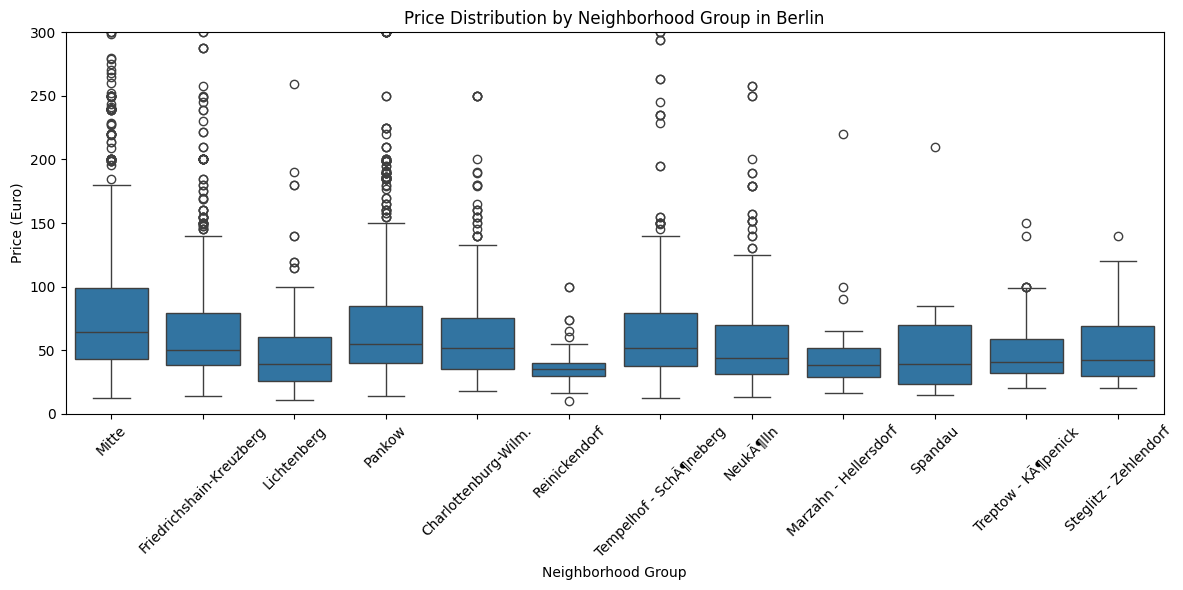

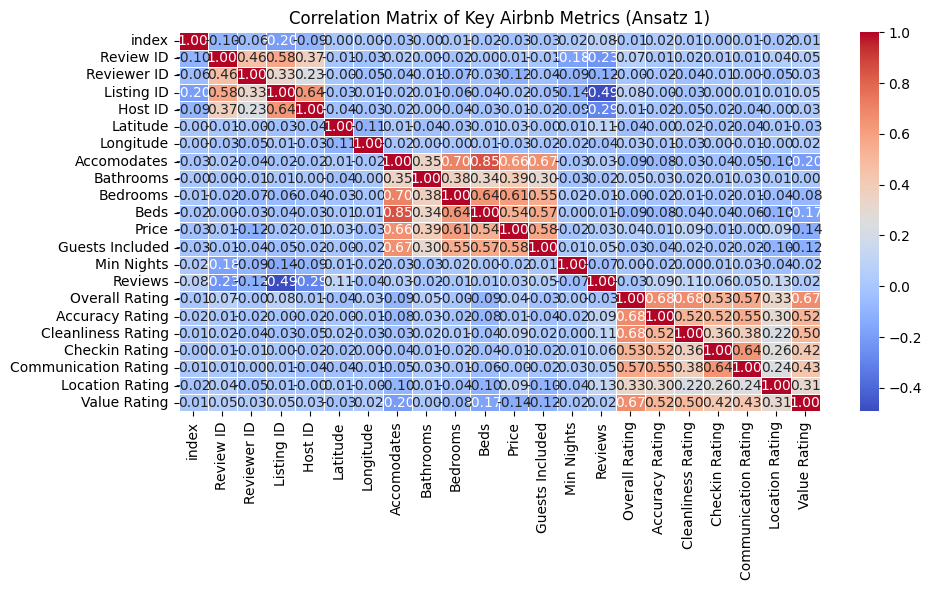

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Descriptive Statistics for prices across different neighborhood groups
print("--- Price Statistics by Neighborhood Group ---")
# Këtu përdorim 'Neighborhood Group' dhe 'Price' me shkronja të mëdha siç i ke ti
price_stats = df.groupby('Neighborhood Group')['Price'].agg(['mean', 'median', 'std', 'count']).round(2)
print(price_stats)

# 2. Visualization: Boxplot for price distribution (filtered up to 300€)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Neighborhood Group', y='Price', data=df)
plt.xticks(rotation=45)
plt.title('Price Distribution by Neighborhood Group in Berlin')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price (Euro)')
plt.ylim(0, 300) 
plt.tight_layout()
plt.show()

# 3. Correlation Matrix and Heatmap
plt.figure(figsize=(10, 6))
# Këtu po zgjedhim vetëm ato kolona që ekzistojnë 100% si numra në datasetin tënd
# Nëse kolonat e tjera kanë gabim emri, kjo pjesë do të na tregojë
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Airbnb Metrics (Ansatz 1)')
plt.tight_layout()
plt.show()

In [8]:
print(df.columns.tolist())

['index', 'Review ID', 'review_date', 'Reviewer ID', 'Reviewer Name', 'Comments', 'Listing ID', 'Listing URL', 'Listing Name', 'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Response Time', 'Host Response Rate', 'Is Superhost', 'neighbourhood', 'Neighborhood Group', 'City', 'Postal Code', 'Country Code', 'Country', 'Latitude', 'Longitude', 'Is Exact Location', 'Property Type', 'Room Type', 'Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Square Feet', 'Price', 'Guests Included', 'Min Nights', 'Reviews', 'First Review', 'Last Review', 'Overall Rating', 'Accuracy Rating', 'Cleanliness Rating', 'Checkin Rating', 'Communication Rating', 'Location Rating', 'Value Rating', 'Instant Bookable', 'Business Travel Ready']


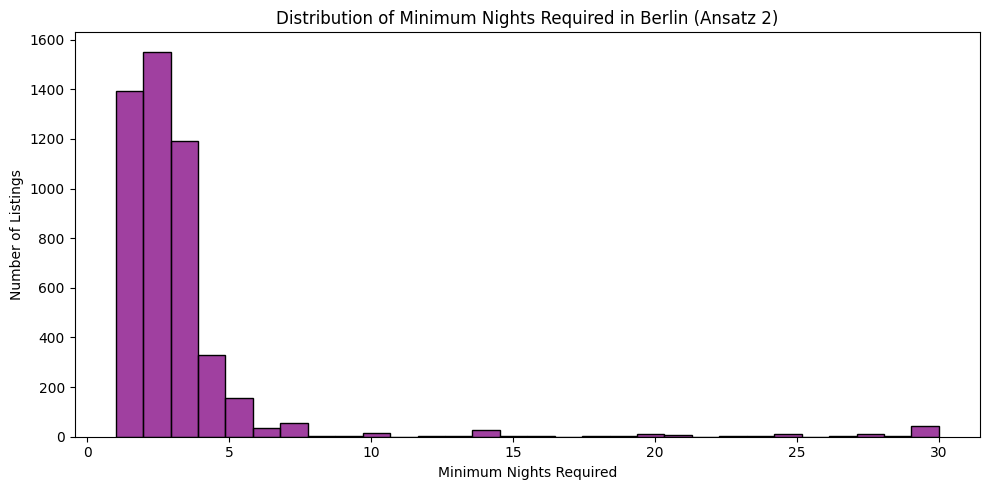

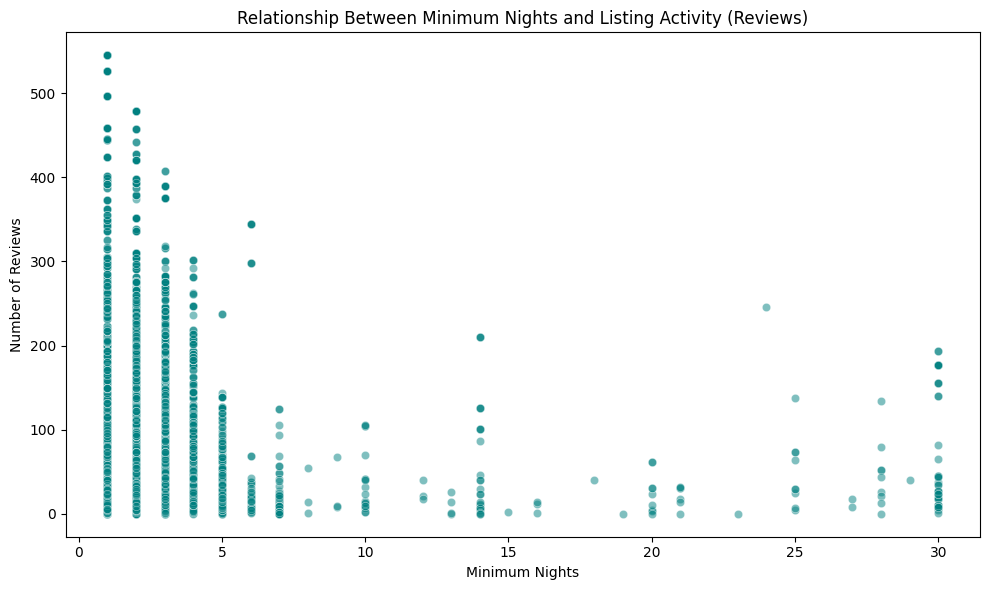

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualization: Distribution of Minimum Nights required by hosts
# This shows if hosts prefer short-term guests or long-term rentals
plt.figure(figsize=(10, 5))
# Filtering up to 30 nights to get a cleaner look at typical rental behaviors
sns.histplot(df[df['Min Nights'] <= 30]['Min Nights'], kde=False, bins=30, color='purple')
plt.title('Distribution of Minimum Nights Required in Berlin (Ansatz 2)')
plt.xlabel('Minimum Nights Required')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

# 2. Scatter Plot: Minimum Nights vs Number of Reviews
# This helps analyze if strict stay requirements impact how active/booked a listing is
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Min Nights', y='Reviews', data=df[df['Min Nights'] <= 30], alpha=0.5, color='teal')
plt.title('Relationship Between Minimum Nights and Listing Activity (Reviews)')
plt.xlabel('Minimum Nights')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

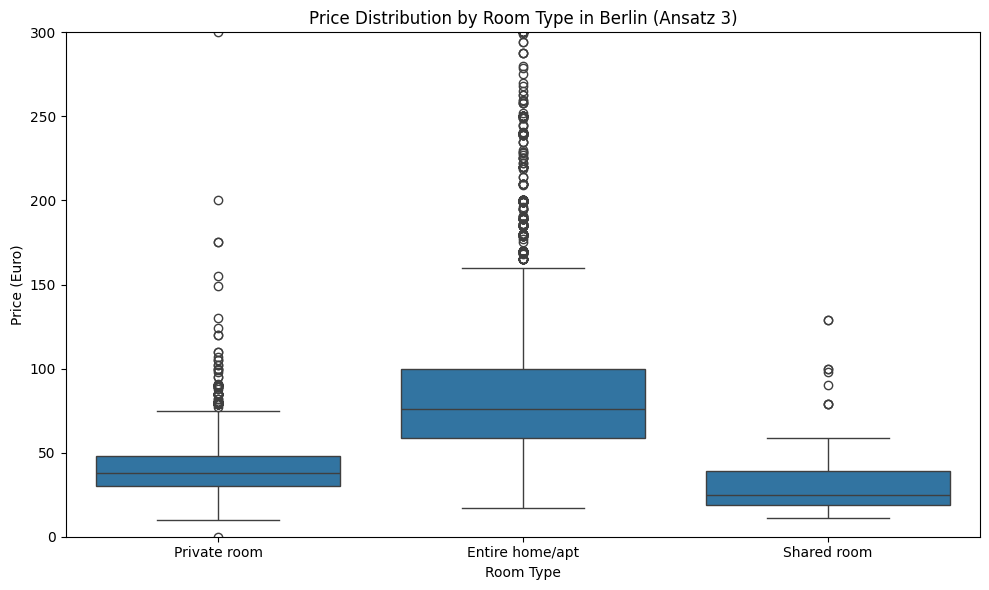

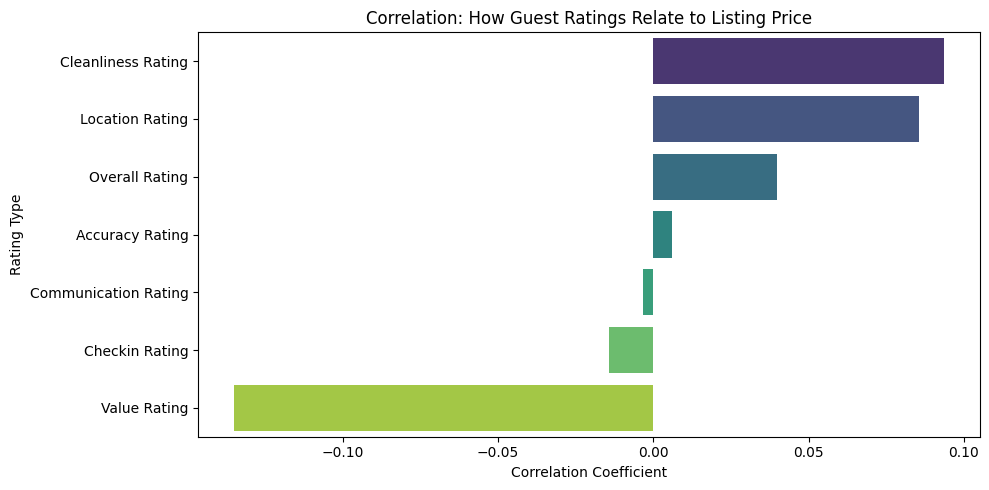

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot: Room Type vs Price
plt.figure(figsize=(10, 6))
sns.boxplot(x='Room Type', y='Price', data=df)
plt.title('Price Distribution by Room Type in Berlin (Ansatz 3)')
plt.xlabel('Room Type')
plt.ylabel('Price (Euro)')
plt.ylim(0, 300) 
plt.tight_layout()
plt.show()

# 2. Bar Plot: Correlation of Ratings with Price (Fixed Warning)
ratings_cols = ['Overall Rating', 'Accuracy Rating', 'Cleanliness Rating', 'Checkin Rating', 'Communication Rating', 'Location Rating', 'Value Rating']
price_corr = df[ratings_cols + ['Price']].corr()['Price'].drop('Price').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
# Fixed by adding hue=price_corr.index and legend=False to satisfy future Seaborn versions
sns.barplot(x=price_corr.values, y=price_corr.index, hue=price_corr.index, palette='viridis', legend=False)
plt.title('Correlation: How Guest Ratings Relate to Listing Price')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Rating Type')
plt.tight_layout()
plt.show()

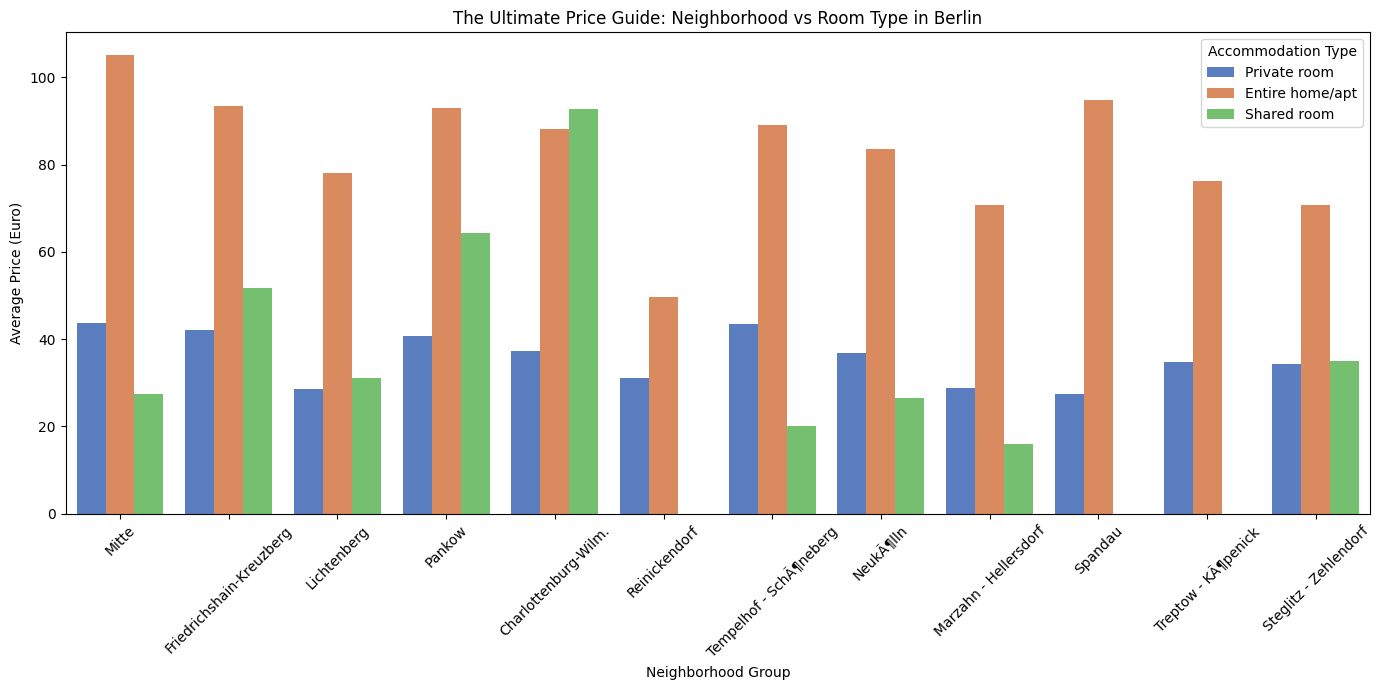

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouped Barplot: Comparing Room Type Prices across different Neighborhoods
plt.figure(figsize=(14, 7))

# We use 'hue' to split each neighborhood into Entire home vs Private room
# This answers the ultimate business question for the project
sns.barplot(x='Neighborhood Group', y='Price', hue='Room Type', data=df, errorbar=None, palette='muted')

plt.xticks(rotation=45)
plt.title('The Ultimate Price Guide: Neighborhood vs Room Type in Berlin')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price (Euro)')
plt.legend(title='Accommodation Type', loc='upper right')
plt.tight_layout()
plt.show()